# Toy TFT on POUS event windows

This notebook uses the real outage event list in `POUS.csv`, extracts small event-centered windows from `timeseries.pq`, and adds synthetic weather columns with the same names you will later get from Earth Engine.

It is deliberately narrow. The goal is to get the pipeline running and let you inspect the data flow before the real weather export finishes.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# warnings.filterwarnings("ignore")

try:
    import duckdb
except ImportError:
    duckdb = None

try:
    import lightning.pytorch as pl
except ImportError:
    import pytorch_lightning as pl

from pytorch_forecasting import Baseline, TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE, QuantileLoss

pl.seed_everything(42)


Seed set to 42


42

If needed, install the small dependency set first:

```bash
pip install duckdb pytorch-forecasting lightning
```

If your environment already has the packages, skip this cell.

In [2]:
# File locations.
base = Path(r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw")
pous_path = base / "POUS.csv"
timeseries_path = base / "timeseries.pq"

print("POUS exists:", pous_path.exists())
print("timeseries exists:", timeseries_path.exists())


POUS exists: True
timeseries exists: True


In [3]:
# Load the event list only.
pous = pd.read_csv(pous_path, parse_dates=["event_start"])

print("POUS shape:", pous.shape)
print("POUS columns:")
print(list(pous.columns))
print("\nHead:")
display(pous.head())


POUS shape: (1040, 13)
POUS columns:
['event_start', 'CountyFIPS', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'duration_hours', 'n_periods', 'integral', 'pop_hours_supply_lost', 'storm', 'duration_days', 'year', 'month']

Head:


,event_start,CountyFIPS,county_pop,pre_outage_tracked_customers,days_since_data_start,duration_hours,n_periods,integral,pop_hours_supply_lost,storm,duration_days,year,month
0,2017-06-21 16:00:00,54001,15414,6599.0,171.625000,47,47,0.389301,6.000692e+03,2017171N24271,1.958333,2017,6
1,2017-06-24 04:00:00,54059,22573,13970.0,174.125000,62,62,4.778789,1.078716e+05,2017171N24271,2.583333,2017,6
2,2017-07-30 21:00:00,12075,45260,2942.7,210.833333,86,86,4.007550,1.813817e+05,2017212N28275,3.583333,2017,7
3,2017-08-24 22:00:00,21055,8981,3092.0,235.875000,52,52,0.500271,4.492933e+03,2017228N14314,2.166667,2017,8
4,2017-08-25 21:00:00,48355,351674,143346.0,236.833333,241,241,59.381195,2.088282e+07,2017228N14314,10.041667,2017,8


In [4]:
# Keep a small event subset for the toy run.
# 15 events is enough to test the plumbing without making the notebook sluggish.
N_EVENTS = 15

pous_small = (
    pous.sample(n=min(N_EVENTS, len(pous)), random_state=42)
        .sort_values(["event_start", "CountyFIPS"])
        .reset_index(drop=True)
        .copy()
)

pous_small["event_id"] = [f"event_{i:03d}" for i in range(len(pous_small))]

print("Selected events:", len(pous_small))
display(pous_small[["event_id", "event_start", "CountyFIPS", "duration_hours", "storm"]].head(10))


Selected events: 15


,event_id,event_start,CountyFIPS,duration_hours,storm
0,event_000,2017-09-01 00:00:00,28053,24,2017228N14314
1,event_001,2017-09-11 14:00:00,13091,58,2017242N16333
2,event_002,2018-05-27 13:00:00,21039,34,2018146N19273
3,event_003,2018-09-17 02:00:00,51077,25,2018242N13343
4,event_004,2018-10-10 21:00:00,13037,195,2018280N18273
5,event_005,2018-10-11 04:00:00,13023,64,2018280N18273
6,event_006,2018-10-12 01:00:00,51073,96,2018280N18273
7,event_007,2019-10-26 13:00:00,28065,53,2019299N25265
8,event_008,2020-08-04 09:00:00,37187,37,2020211N13306
9,event_009,2020-08-27 07:00:00,22045,56,2020233N14313


In [5]:
def load_event_window(ts_path, county_fips, start_dt, end_dt):
    """Read one county window from the parquet file without loading the full archive."""
    county_fips = str(county_fips).zfill(5)
    start_dt = pd.Timestamp(start_dt).to_pydatetime()
    end_dt = pd.Timestamp(end_dt).to_pydatetime()

    if duckdb is None:
        raise ImportError("duckdb is not installed. Run: pip install duckdb")

    query = """
        SELECT
            RecordDateTime AS datetime,
            CountyFIPS,
            OutageFraction,
            CustomersTracked
        FROM read_parquet(?)
        WHERE CountyFIPS = ?
          AND RecordDateTime BETWEEN ? AND ?
        ORDER BY RecordDateTime
    """

    out = duckdb.execute(query, [str(ts_path), county_fips, start_dt, end_dt]).df()
    if not out.empty:
        out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
        out["datetime"] = pd.to_datetime(out["datetime"])
    return out


In [ ]:
# Extract event-centered outage windows.
# Window definition:
#   12 hours before event start
#   through event duration + 12 hours after event start
#                                                 ^ SHOULD THIS BE AFTER EVENT END??? yes, it appears that's what the math is doing

PRE_HOURS = 12
POST_HOURS = 12

windows = []
skipped = []

for row in pous_small.itertuples(index=False):
    event_start = pd.Timestamp(row.event_start)
    event_end = event_start + pd.Timedelta(hours=float(row.duration_hours))
    window_start = event_start - pd.Timedelta(hours=PRE_HOURS)
    window_end = event_end + pd.Timedelta(hours=POST_HOURS)

    ts = load_event_window(
        timeseries_path,
        row.CountyFIPS,
        window_start,
        window_end,
    )

    if ts.empty:
        skipped.append((row.event_id, row.CountyFIPS))
        continue

    ts = ts.sort_values("datetime").reset_index(drop=True)
    ts["event_id"] = row.event_id
    ts["CountyFIPS"] = str(row.CountyFIPS).zfill(5) # to ensure we get leading zeros on the 5-dig code
    ts["storm"] = row.storm
    ts["event_start"] = event_start
    ts["duration_hours"] = float(row.duration_hours)
    ts["window_start"] = window_start
    ts["window_end"] = window_end
    ts["hours_from_event_start"] = (ts["datetime"] - event_start).dt.total_seconds() / 3600.0
    ts["time_idx"] = np.arange(len(ts), dtype=int)

    windows.append(ts)

print("Built windows:", len(windows))
print("Skipped events:", len(skipped))
if skipped:
    print("First skipped:", skipped[:5])


Built windows: 15
Skipped events: 0


In [7]:
# Stack all windows into one dataframe.
outages = pd.concat(windows, ignore_index=True)

# Keep only what we need for the toy TFT.
outages = outages[[
    "event_id",
    "CountyFIPS",
    "storm",
    "event_start",
    "duration_hours",
    "window_start",
    "window_end",
    "datetime",
    "time_idx",
    "hours_from_event_start",
    "OutageFraction",
    "CustomersTracked",
]].copy()

outages = outages.rename(columns={
    "OutageFraction": "outageFraction",
    "CustomersTracked": "customersTracked",
})

print("Outage window table shape:", outages.shape)
display(outages.head())


Outage window table shape: (1478, 12)


,event_id,CountyFIPS,storm,event_start,duration_hours,window_start,window_end,datetime,time_idx,hours_from_event_start,outageFraction,customersTracked
0,event_000,28053,2017228N14314,2017-09-01,24.0,2017-08-31 12:00:00,2017-09-02 12:00:00,2017-08-31 12:00:00,0,-12.0,0.0,2644.0
1,event_000,28053,2017228N14314,2017-09-01,24.0,2017-08-31 12:00:00,2017-09-02 12:00:00,2017-08-31 13:00:00,1,-11.0,0.0,2644.0
2,event_000,28053,2017228N14314,2017-09-01,24.0,2017-08-31 12:00:00,2017-09-02 12:00:00,2017-08-31 14:00:00,2,-10.0,0.0,2644.0
3,event_000,28053,2017228N14314,2017-09-01,24.0,2017-08-31 12:00:00,2017-09-02 12:00:00,2017-08-31 15:00:00,3,-9.0,0.0,2644.0
4,event_000,28053,2017228N14314,2017-09-01,24.0,2017-08-31 12:00:00,2017-09-02 12:00:00,2017-08-31 16:00:00,4,-8.0,0.0,2644.0


In [8]:
# Add synthetic weather with the same column names you plan to export from GEE.
# The aim is not realism. The aim is to test the TFT plumbing.

rng = np.random.default_rng(42)
outages = outages.copy()

# Event-level severity proxy to make the synthetic weather structured.
severity = outages.groupby("event_id")["duration_hours"].transform("first")
rel = outages["hours_from_event_start"].to_numpy()

peak = 8.0 + 0.04 * severity.to_numpy()
center = 0.0
sigma = 8.0

storm_shape = np.exp(-0.5 * ((rel - center) / sigma) ** 2)

outages["gust_mps"] = np.clip(
    4.0 + peak * storm_shape + rng.normal(0, 0.8, len(outages)),
    0,
    None,
)

outages["wind_speed_mps"] = np.clip(
    0.7 * outages["gust_mps"].to_numpy() + rng.normal(0, 0.5, len(outages)),
    0,
    None,
)

outages["precip_mm"] = np.clip(
    0.2 * outages["gust_mps"].to_numpy() + rng.normal(0, 0.7, len(outages)),
    0,
    None,
)

outages["pressure_hpa"] = np.clip(
    1013.0 - 0.9 * outages["gust_mps"].to_numpy() + rng.normal(0, 1.5, len(outages)),
    960,
    1035,
)

month = pd.to_datetime(outages["datetime"]).dt.month.to_numpy()
outages["temp_c"] = 25.0 + 6.0 * np.sin((month - 1) * 2 * np.pi / 12.0) + rng.normal(0, 1.0, len(outages))

print("Synthetic weather columns added.")
display(outages[["event_id", "datetime", "outageFraction", "gust_mps", "wind_speed_mps", "precip_mm", "pressure_hpa", "temp_c"]].head())


Synthetic weather columns added.


,event_id,datetime,outageFraction,gust_mps,wind_speed_mps,precip_mm,pressure_hpa,temp_c
0,event_000,2017-08-31 12:00:00,0.0,7.152660,4.811523,1.802388,1009.424529,22.574354
1,event_000,2017-08-31 13:00:00,0.0,6.649494,5.507572,1.409558,1008.287266,21.846450
2,event_000,2017-08-31 14:00:00,0.0,8.702548,6.316773,1.869566,1004.533336,22.528019
3,event_000,2017-08-31 15:00:00,0.0,9.511072,6.939407,3.267875,1005.667140,22.313965
4,event_000,2017-08-31 16:00:00,0.0,7.873687,5.568873,0.686375,1003.817186,22.058264


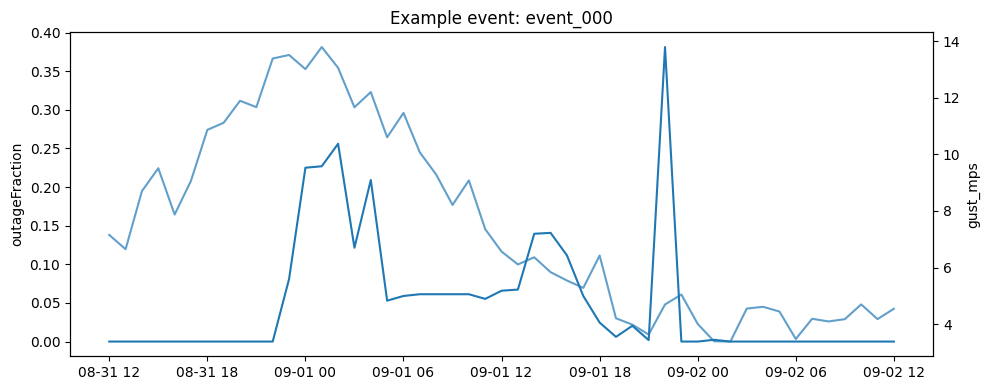

In [9]:
# Quick visual check for one event.
example_event = outages["event_id"].iloc[0]
ex = outages[outages["event_id"] == example_event].copy()

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(ex["datetime"], ex["outageFraction"], label="outageFraction")
ax1.set_ylabel("outageFraction")
ax1.set_title(f"Example event: {example_event}")
ax2 = ax1.twinx()
ax2.plot(ex["datetime"], ex["gust_mps"], label="gust_mps", alpha=0.7)
ax2.set_ylabel("gust_mps")
fig.tight_layout()
plt.show()


In [10]:
# Prepare the model table.
# Each event is an independent sequence.
model_df = outages.copy()
model_df["CountyFIPS"] = model_df["CountyFIPS"].astype(str)
model_df["event_id"] = model_df["event_id"].astype(str)

# Keep only the columns used by the toy TFT.
model_df = model_df[[
    "event_id",
    "CountyFIPS",
    "time_idx",
    "outageFraction",
    "gust_mps",
    "wind_speed_mps",
    "precip_mm",
    "pressure_hpa",
    "temp_c",
]].copy()

print(model_df.shape)
display(model_df.head())


(1478, 9)


,event_id,CountyFIPS,time_idx,outageFraction,gust_mps,wind_speed_mps,precip_mm,pressure_hpa,temp_c
0,event_000,28053,0,0.0,7.152660,4.811523,1.802388,1009.424529,22.574354
1,event_000,28053,1,0.0,6.649494,5.507572,1.409558,1008.287266,21.846450
2,event_000,28053,2,0.0,8.702548,6.316773,1.869566,1004.533336,22.528019
3,event_000,28053,3,0.0,9.511072,6.939407,3.267875,1005.667140,22.313965
4,event_000,28053,4,0.0,7.873687,5.568873,0.686375,1003.817186,22.058264


In [11]:
# Train/validation split by event.
event_ids = model_df["event_id"].drop_duplicates().tolist()
cut = max(1, int(0.8 * len(event_ids)))
train_event_ids = event_ids[:cut]
val_event_ids = event_ids[cut:]

train_df = model_df[model_df["event_id"].isin(train_event_ids)].copy()
val_df = model_df[model_df["event_id"].isin(val_event_ids)].copy()

print("Train events:", len(train_event_ids))
print("Val events:", len(val_event_ids))
print("Train rows:", len(train_df))
print("Val rows:", len(val_df))


Train events: 12
Val events: 3
Train rows: 1068
Val rows: 410


In [12]:
# Build TFT datasets.
max_encoder_length = 48
max_prediction_length = 12

training = TimeSeriesDataSet(
    train_df,
    time_idx="time_idx",
    target="outageFraction",
    group_ids=["event_id"],
    min_encoder_length=24,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["CountyFIPS"],
    time_varying_known_reals=["time_idx", "gust_mps", "wind_speed_mps", "precip_mm", "pressure_hpa", "temp_c"],
    time_varying_unknown_reals=["outageFraction"],
    target_normalizer=GroupNormalizer(groups=["CountyFIPS"]),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    val_df,
    predict=True,
    stop_randomization=True,
)

train_loader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=128, num_workers=0)

print(training)


KeyError: "Unknown category 'event_012' encountered. Set `add_nan=True` to allow unknown categories"

In [ ]:
# Baseline check.
baseline = Baseline()
baseline_pred = baseline.predict(val_loader, return_y=True)
baseline_mae = MAE()(baseline_pred.output, baseline_pred.y)
print("Baseline MAE:", float(baseline_mae))


In [ ]:
# Tiny TFT.
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=8,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=3,
)

print("Model size:", tft.size())

trainer = pl.Trainer(
    max_epochs=5,
    accelerator="auto",
    devices="auto",
    gradient_clip_val=0.1,
    enable_checkpointing=False,
    logger=True,
)

trainer.fit(tft, train_loader, val_loader)


In [ ]:
# Validation metric.
pred = tft.predict(val_loader, return_y=True)
tft_mae = MAE()(pred.output, pred.y)
print("TFT MAE:", float(tft_mae))


At this point you should have a working toy pipeline. The next useful step is to inspect one validation batch and add a prediction plot only after the data-loading and training cells run cleanly.